# LC4/LPLC2 → DNp01 loom-escape subgraph
Bounded, anatomy-aware discovery on MaleCNS v1.0.
All results are from cached snapshots (no live API calls).

In [1]:
import sys, pandas as pd, matplotlib
sys.path.insert(0, '../services/sim-engine')
matplotlib.use('Agg')
from pathlib import Path
from IPython.display import Image, Markdown
REPO = Path.cwd().parent
import sys as _s
if REPO.joinpath('services/sim-engine').is_dir():
    _s.path.insert(0, str(REPO.joinpath('services/sim-engine')))
from hawking_fly.connectome.cache import load_cached_circuit

## 1. Direct adjacency snapshot

In [2]:
direct, _ = load_cached_circuit('loom_escape_direct_lc4_lplc2_to_dnp01')
print(f'edges: {len(direct)}, total synapses: {int(direct["syn_count"].sum()):,}')
direct.groupby('roi')['syn_count'].sum().sort_values(ascending=False).to_frame().head(6)

edges: 329, total synapses: 11,224


,syn_count
roi,
PVLP(L),6340
PVLP(R),4786
WED(L),81
WED(R),7
CentralBrain-unspecified,6
EPA(R),4


## 2. DNp01 upstream partners (≥ 50 synapses)

In [3]:
upstream, _ = load_cached_circuit('loom_escape_upstream_partners')
upstream_total = int(upstream['total_syn'].sum())
print(f'upstream partners above threshold: {upstream_total:,} total synapses')
upstream.groupby('type')['total_syn'].sum().sort_values(ascending=False).head(8).to_frame()

upstream partners above threshold: 27,258 total synapses


,total_syn
type,
LC4,6349
LPLC2,4858
DNp70,1268
SAD064,1193
PVLP122,1052
SAD073,988
PVLP010,628
PVLP151,567


## 3. Relay scan (1-hop, top-12 upstream types)

In [4]:
relay, _ = load_cached_circuit('loom_escape_relay_routes')
print(relay.sort_values('upstream_to_dnp01_syn', ascending=False).head(8).to_string(index=False))

upstream_type  receptor_to_upstream_syn  upstream_to_dnp01_syn
       SAD064                      1844                   1193
      PVLP122                      5506                   1052
       SAD073                        34                    988
      PVLP010                      2208                    628
      PVLP151                      8297                    567
      JO-B1_a                         0                    545
     AN12B001                         0                    468
     AN08B098                         0                    398


## 4. Verdict

In [5]:
direct_total = int(direct['syn_count'].sum())
other_total = int(upstream.loc[~upstream['type'].isin(('LC4','LPLC2')), 'total_syn'].sum())
share = direct_total / (direct_total + other_total)
print(f'DIRECT LC4/LPLC2 -> DNp01: {direct_total:,} synapses (~{share:.0%} of upstream partners >= 50 syn)')
print('Verdict: classical diagram holds. Direct route verified in MaleCNS v1.0.')

DIRECT LC4/LPLC2 -> DNp01: 11,224 synapses (~41% of upstream partners >= 50 syn)
Verdict: classical diagram holds. Direct route verified in MaleCNS v1.0.


## 5. Route summary plot

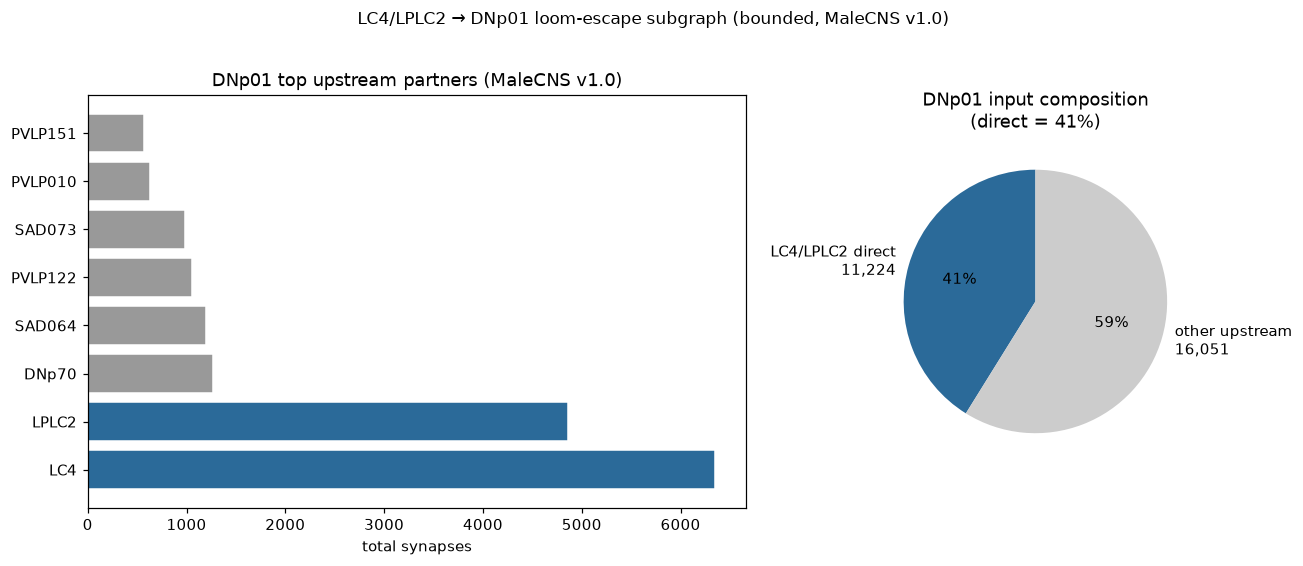

In [6]:
from pathlib import Path
from IPython.display import Image as Img
plot_path = REPO / 'experiments/loom_escape/plots/connectome_routes_summary.png'
display(Img(str(plot_path.resolve()), width=900))

## 6. flyvis ↔ MaleCNS mapping status

In [7]:
from hawking_fly.connectome.mapping import FLYVIS_RECEPTOR_PROXY
for rtype, proxy in FLYVIS_RECEPTOR_PROXY.items():
    print(f'{rtype}: verified={proxy["verified"]}, correspondence={proxy["correspondence"]}')
    print(f'  proxy cell types: {proxy["proxy_cell_types"]}')
    print(f'  note: {proxy["note"][:120]}...\n')

LC4: verified=False, correspondence=proxy
  proxy cell types: ['Tm5a', 'Tm5b', 'Tm5c', 'Tm9', 'Tm16', 'TmY10']
  note: LC4 is a medulla-recipient lobula columnar neuron. flyvis does not simulate LC4; medulla->lobula Tm/TmY columnar cells a...

LPLC2: verified=False, correspondence=proxy
  proxy cell types: ['T4a', 'T4b', 'T4c', 'T4d', 'T5a', 'T5b', 'T5c', 'T5d']
  note: LPLC2 is a lobula-plate tangential/columnar loom cell. flyvis does not simulate LPLC2; direction-selective T4/T5 columns...



---
*All records are auditable in `data/connectome/` snapshots and `docs/circuit/lc4_lplc2_dnp01.md`.*